In [1]:
#Start

#!/usr/bin/env python
# coding: utf-8
import pandas as pd
from pathlib import Path

DATA_DIR = Path("../data")
OUTPUT_DIR = Path("../outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

In [2]:
# Import the data from the xlsx file into a data frame

df = pd.read_excel(DATA_DIR / "business_financials.xlsx")

In [3]:
# Identify if there are any duplicate rows in the data frame
duplicates = df.duplicated()

In [4]:
# Handle duplicates found in the data frame by removing them before proceeding

if df.duplicated().any():
    df_cleaned = df.drop_duplicates()   #Remove dupes
    df = df_cleaned     # assigns the cleaned data frame back to df to continue with the analysis
    print("There were duplicates found in the data and they are now removed.")
else:
    print("There were no duplicates found.")


There were no duplicates found.


In [5]:
# Group the businesses by state

df2 = df.groupby("Business State").mean(numeric_only=True)

In [6]:
# Calculate the mean, median, and mode for all numeric variables within each state

# List of columns to aggregate
columns = [
    "Total Long-term Debt", "Total Equity", "Debt to Equity",
    "Total Liabilities", "Total Revenue", "Profit Margin"
]

# Aggregation functions
agg_funcs = ["mean", "median", "min", "max"]

# Create the aggregation dictionary
agg_dict = {f"{col}_{func}": (col, func) for col in columns for func in agg_funcs}

In [7]:
# Store the statistical results in a new data frame
df2 = df.groupby("Business State").agg(**agg_dict)

# Ensure that our new data frame  was created, grouped, and calculated as planned
df2

# Save the grouped statistics as a reproducible output artifact.
df2.reset_index().to_excel(OUTPUT_DIR / "state_statistics.xlsx", index=False)


In [8]:
# Filter data frame where the debt-to-equity ratio is negative ( less than zero )

df_filtered = df[df["Debt to Equity"] < 0]

# Check
df_filtered

,Business ID,Business State,Total Long-term Debt,Total Equity,Debt to Equity,Total Liabilities,Total Revenue,Profit Margin
18,934562013,Ohio,263880000.0,-111297000.0,-2.370953,592174000.0,719783000,0.320697
57,8343652013,Washington,10603000.0,-13271658.0,-0.798921,16625000.0,8949401,0.448119
87,9323722013,California,21560000.0,-15691000.0,-1.374036,30048000.0,37782000,0.505955
109,10919832013,Utah,2010000.0,-3602481.0,-0.557949,6302000.0,17757388,0.732562
117,11245242013,California,556000.0,-2063203.0,-0.269484,3819000.0,1100539,-0.084923
142,14535932013,Montana,16459000.0,-3842372.0,-4.283552,32720000.0,33073414,0.582444
143,14639722013,New York,187000.0,-13037879.0,-0.014343,15900000.0,2389053,0.300978


In [9]:
# Create a new data frame that displays the debt-to-income for all companies

# Calculate the debt-to-income ratio
df['Debt to Income'] = df['Total Long-term Debt'] / df['Total Revenue']

# Create a new DataFrame with the debt-to-income ratio
df_debt_to_income = df[['Debt to Income']]

# Save debt-to-equity summaries used by the coursework deliverable.
df_de_ratio_by_state = df.groupby("Business State", as_index=False)["Debt to Equity"].mean()
df_de_ratio_by_state.to_excel(
    OUTPUT_DIR / "businesses_grouped_by_state_debt_to_equity_ratio.xlsx",
    sheet_name="Debt to Equity Ratio by State",
    index=False,
)
df_de_ratio_by_state.sort_values("Debt to Equity").to_excel(
    OUTPUT_DIR / "debt_to_equity_ratio_by_state.xlsx",
    sheet_name="Debt to Equity Ratio",
    index=False,
)


In [10]:
# Concatenate the debt-to-income data frame created with the original data frame

df_combined = pd.concat([df, df_debt_to_income['Debt to Income']], axis=1)

In [11]:
# End

#view the fixed data frame
df



,Business ID,Business State,Total Long-term Debt,Total Equity,Debt to Equity,Total Liabilities,Total Revenue,Profit Margin,Debt to Income
0,41872013,Kentucky,16889000.0,1.804600e+07,0.935886,2.598600e+07,136753000,0.023663,0.123500
1,76232013,Iowa,6252000.0,1.829362e+07,0.341758,1.447400e+07,34226553,0.265015,0.182665
2,160992013,Texas,19200000.0,1.778580e+08,0.107951,7.278700e+07,384196000,0.130413,0.049974
3,197452013,Delaware,117592000.0,2.787730e+08,0.421820,5.587490e+08,444306000,0.196768,0.264664
4,241042013,Illinois,4408000.0,5.206400e+07,0.084665,1.989800e+07,121541000,0.168305,0.036268
...,...,...,...,...,...,...,...,...,...
145,14733342013,California,6602000.0,3.872871e+07,0.170468,2.183800e+07,78356493,0.213007,0.084256
146,14871012013,Maryland,56000000.0,2.813310e+08,0.199054,1.476180e+08,298732000,0.353230,0.187459
147,14889172013,MInnesota,1332000.0,1.392683e+07,0.095643,3.629000e+06,15104422,0.727563,0.088186
148,15456542013,Hawaii,605500000.0,1.173200e+09,0.516110,1.110400e+09,365200000,0.348850,1.657996


In [12]:
# No sources were used for this code.

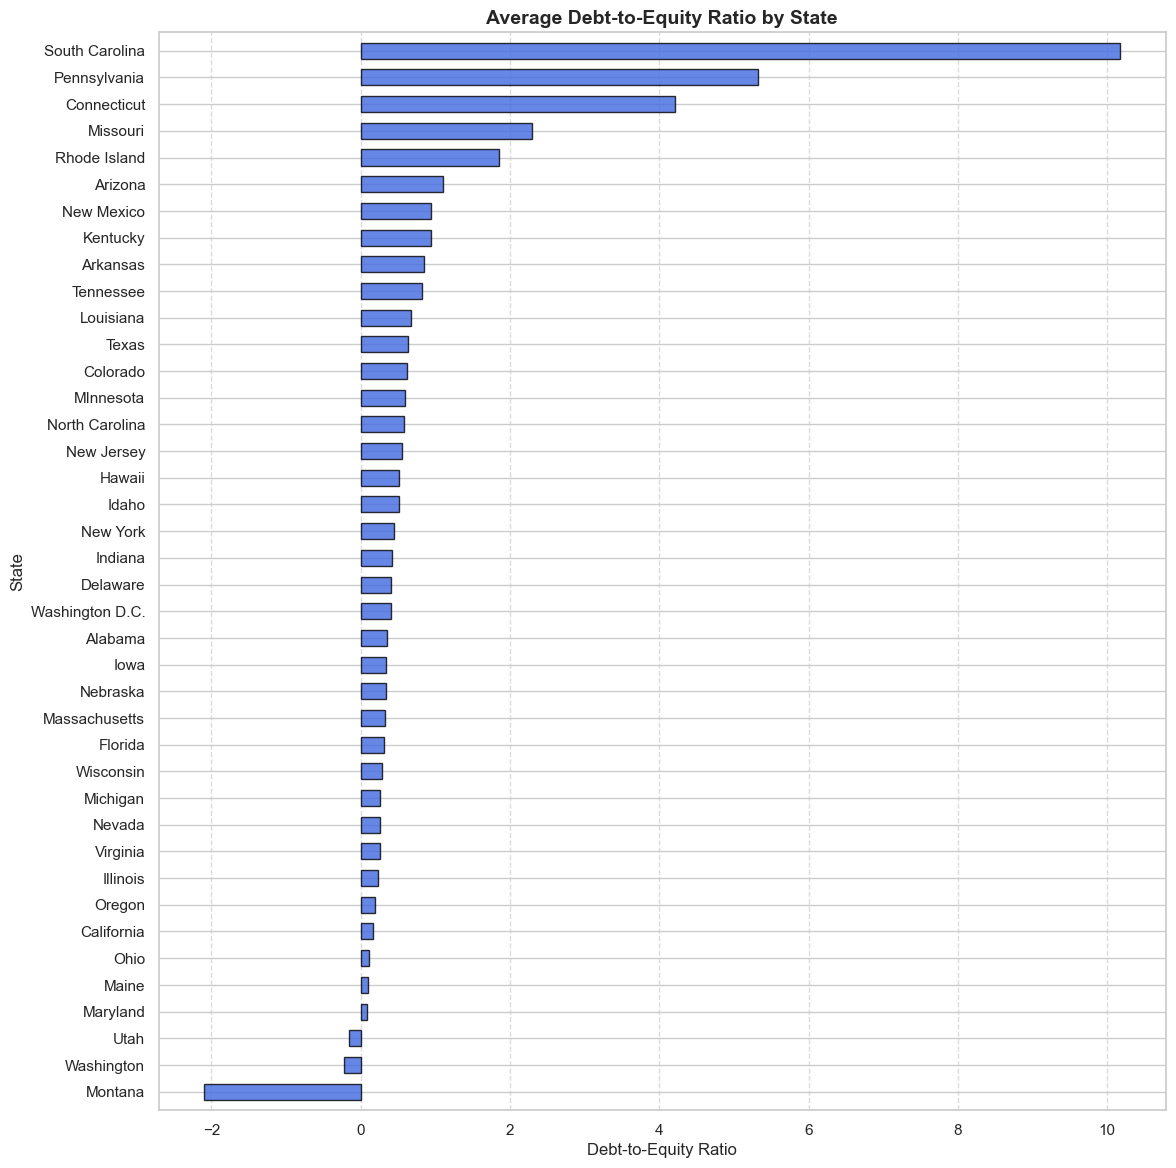

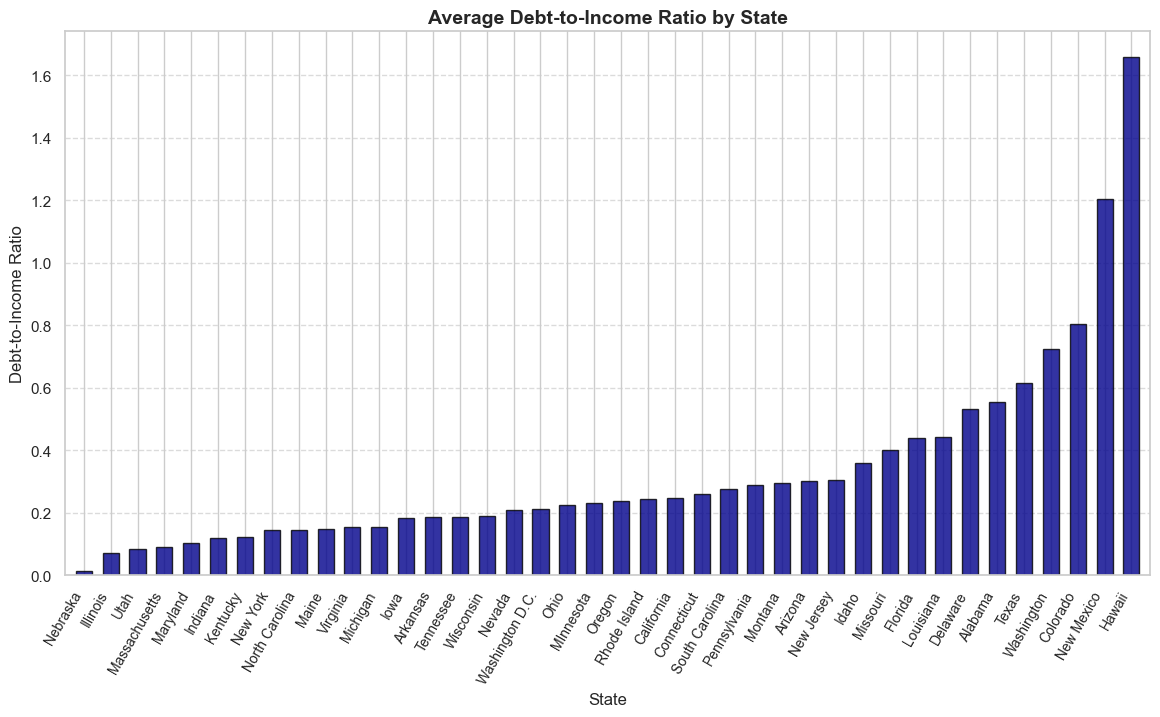

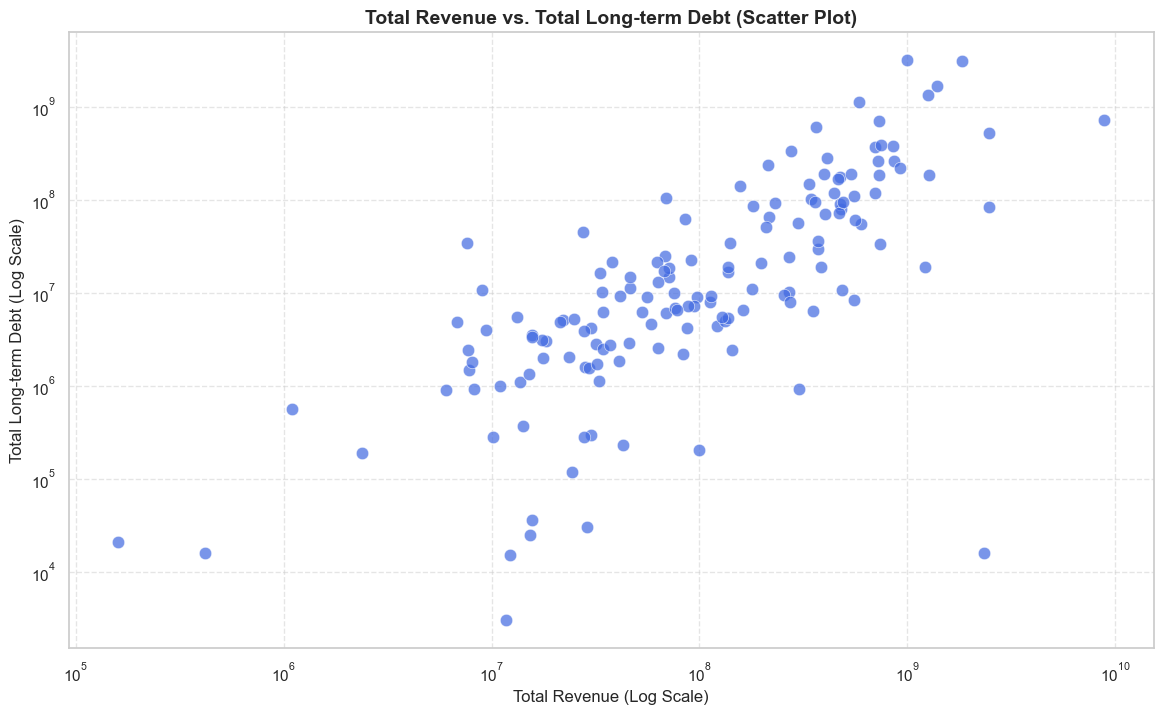

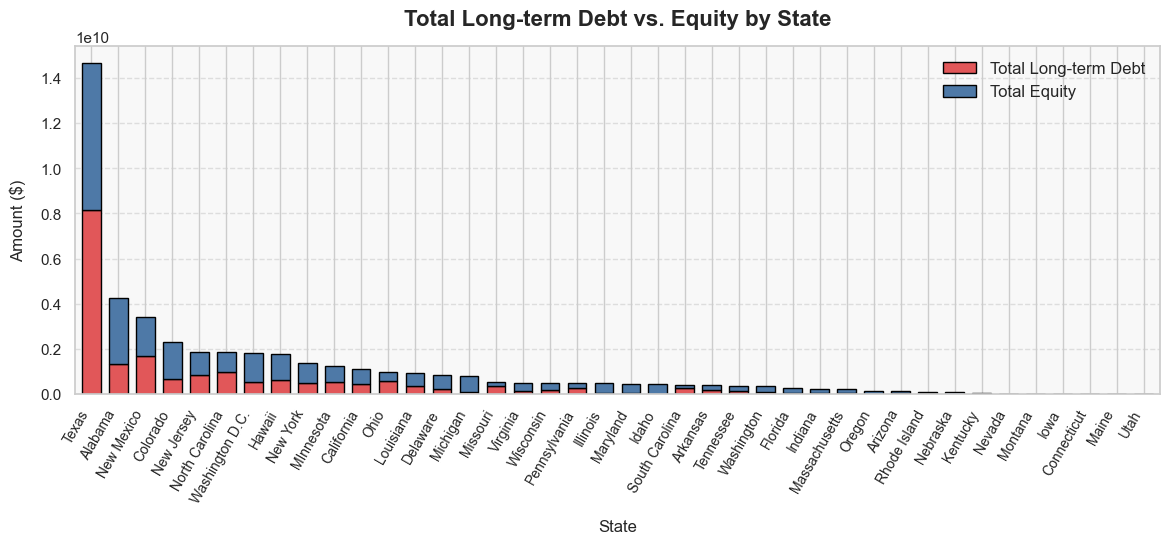

In [13]:
import matplotlib.pyplot as plt  # Importing Matplotlib for plotting
import seaborn as sns  # Importing Seaborn for styling the visualizations

# Set a clean and professional style for all visualizations
sns.set_theme(style="whitegrid")

# ==================================================
# VISUAL 1: HORIZONTAL BAR CHART (DEBT-TO-EQUITY RATIO BY STATE)
# ==================================================

# Create a new figure with a specific size for readability
plt.figure(figsize=(13,14))

# Group the dataset by state, calculate the average Debt-to-Equity ratio per state, 
# and sort the values in ascending order for better visualization.
df_avg_de_ratio = df.groupby("Business State")["Debt to Equity"].mean().sort_values()

# Create a horizontal bar chart where:
# - The y-axis represents states, 
# - The x-axis represents the Debt-to-Equity Ratio,
# - Each bar represents a state’s average Debt-to-Equity Ratio.
ax = plt.barh(df_avg_de_ratio.index, df_avg_de_ratio.values, 
              color='royalblue', edgecolor="black", alpha=0.8, height=0.6)

# Add a title to clearly indicate what the chart represents
plt.title("Average Debt-to-Equity Ratio by State", fontsize=14, fontweight='bold')

# Label the x-axis (horizontal axis) to clarify what the numbers represent
plt.xlabel("Debt-to-Equity Ratio", fontsize=12)

# Label the y-axis (vertical axis) to indicate that it represents states
plt.ylabel("State", fontsize=12)

# Adjust the font size of state labels to ensure they remain readable
plt.yticks(fontsize=11)

# Remove unnecessary empty space around the bars to keep the visualization compact
plt.margins(y=0.01)

# Add a grid along the x-axis (debt-to-equity ratio) for easier value comparison
plt.grid(axis="x", linestyle="--", alpha=0.7)

# Display the visualization
plt.show()

# ==================================================
# VISUAL 2: VERTICAL BAR CHART (DEBT-TO-INCOME RATIO BY STATE)
# ==================================================

# Create a figure with a wide aspect ratio to fit all state labels
plt.figure(figsize=(14,8))

# Group data by state, calculate the average Debt-to-Income ratio, and sort values
df_avg_dti = df.groupby("Business State")["Debt to Income"].mean().sort_values()

# Create a vertical bar chart:
# - The x-axis represents states
# - The y-axis represents the average Debt-to-Income ratio
# - Each bar shows the ratio for a specific state
plt.bar(df_avg_dti.index, df_avg_dti.values, color="darkblue", edgecolor="black", alpha=0.8, width=0.6)

# Title of the visualization
plt.title("Average Debt-to-Income Ratio by State", fontsize=14, fontweight='bold')

# X-axis label to indicate that states are represented
plt.xlabel("State", fontsize=12)

# Y-axis label to indicate the Debt-to-Income ratio
plt.ylabel("Debt-to-Income Ratio", fontsize=12)

# Reduce extra padding on the left and right sides of the graph
plt.margins(x=0.01)

# Rotate state names by 60 degrees to prevent overlapping and make them readable
plt.xticks(rotation=60, ha="right", fontsize=10)

# Adjust bottom margin to prevent labels from getting cut off
plt.subplots_adjust(bottom=0.2)

# Add a grid along the y-axis to make value comparison easier
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Display the visualization
plt.show()

# ==================================================
# VISUAL 3: BUBBLE CHART (TOTAL REVENUE VS. TOTAL LONG-TERM DEBT)
# ==================================================

# Create a figure with a wide aspect ratio for nice visualization
plt.figure(figsize=(14,8))

# Use a logarithmic scale on both axes:
# - This ensures better visualization when data values vary greatly.
plt.xscale("log")
plt.yscale("log")

# Create a scatter plot where:
# - The x-axis represents Total Revenue
# - The y-axis represents Total Long-term Debt
# - The size of all points is the same (s=80)
# - The color is set to blue for a uniform appearance
plt.scatter(df["Total Revenue"], df["Total Long-term Debt"], 
            s=80, alpha=0.7, color="royalblue", 
            edgecolors="white", linewidth=0.5)

# Add a title to describe the visualization
plt.title("Total Revenue vs. Total Long-term Debt (Scatter Plot)", fontsize=14, fontweight='bold')

# Label the x-axis with a note about the logarithmic scale
plt.xlabel("Total Revenue (Log Scale)", fontsize=12)

# Label the y-axis with a note about the logarithmic scale
plt.ylabel("Total Long-term Debt (Log Scale)", fontsize=12)

# Add a light grid to enhance readability
plt.grid(True, linestyle="--", alpha=0.5)

# Display the visualization
plt.show()


# ==================================================
# VISUAL 4: STACKED BAR CHART (TOTAL DEBT VS. EQUITY BY STATE)
# ==================================================

# Group the dataset by state and sum the Total Long-term Debt and Total Equity
df_state_financials = df.groupby("Business State")[["Total Long-term Debt", "Total Equity"]].sum()

# Calculate the total financials (Debt + Equity) per state for sorting purposes
df_state_financials["Total"] = df_state_financials["Total Long-term Debt"] + df_state_financials["Total Equity"]

# Sort the data by Total financials (Debt + Equity) in descending order
df_state_financials = df_state_financials.sort_values(by="Total", ascending=False).drop(columns=["Total"])

# Create a new figure with a suitable width
plt.figure(figsize=(14,6))

# Create a stacked bar chart where:
# - Red represents Total Long-term Debt
# - Blue represents Total Equity
# - The bars are stacked to show how much of each state’s financials come from debt vs. equity
ax = df_state_financials.plot(kind="bar", stacked=True, figsize=(14,6),
                              color=["#E15759", "#4E79A7"], edgecolor="black", width=0.7, ax=plt.gca())

# Add a title to describe the visualization
plt.title("Total Long-term Debt vs. Equity by State", fontsize=16, fontweight='bold', pad=15)

# Label the x-axis
plt.xlabel("State", fontsize=12, labelpad=10)

# Label the y-axis
plt.ylabel("Amount ($)", fontsize=12, labelpad=10)

# Rotate state names on the x-axis for better readability
plt.xticks(rotation=60, ha="right", fontsize=10)

# Adjust bottom margin to prevent label cutoff
plt.subplots_adjust(bottom=0.3)

# Remove extra padding on the sides
plt.margins(x=0.01)

# Move legend to upper right for better positioning
plt.legend(["Total Long-term Debt", "Total Equity"], loc="upper right", fontsize=12, frameon=False)

# Add gridlines for better readability
plt.grid(axis="y", linestyle="--", alpha=0.6)

# Set a light background to improve contrast
plt.gca().set_facecolor("#f8f8f8")

# Display the visualization
plt.show()
